In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.ensemble import BalancedRandomForestClassifier

In [4]:
df = pd.read_csv("/content/cleaned_tele_dataset.csv")

In [5]:
df.head()

,account.length,voice.messages,intl.mins,intl.calls,intl.charge,day.mins,day.calls,day.charge,eve.mins,eve.calls,...,night.calls,night.charge,customer.calls,voice.plan,intl.plan,state,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,0.703644,1.284860,-0.102827,-0.609569,-0.103686,1.581473,0.506326,1.581732,-0.064099,-0.061097,...,-0.452054,0.884585,-0.439508,1,0,16,0,0,1,0
1,0.172149,1.359216,1.276052,-0.609569,1.277442,-0.349141,1.168469,-0.349921,-0.102057,0.141967,...,0.156050,1.079825,-0.439508,1,0,35,0,0,1,0
2,0.931427,-0.574045,0.717047,0.273608,0.711180,1.176697,0.710062,1.176744,-1.586395,0.497330,...,0.206725,-0.752770,-1.343288,0,0,31,0,0,1,0
3,-0.409965,-0.574045,-1.369905,1.156785,-1.374323,2.221281,-1.480104,2.221592,-2.718527,-0.619524,...,-0.553405,-0.069429,0.464272,0,1,35,0,1,0,0
4,-0.637749,-0.574045,-0.065560,-0.609569,-0.062252,-0.254010,0.659128,-0.254436,-1.045001,1.106523,...,1.068205,-0.269107,1.368052,0,1,36,0,0,1,0


In [6]:
replace = {
    "area.code":"area_code",
    "account.length":"account_length",
    "voice.plan":"voice_plan",
    "voice.messages":"voice_messages",
    "intl.plan":"intl_plan",
    "intl.mins":"intl_mins",
    "intl.calls":"intl_calls",
    "intl.charge":"intl_charge",
    "day.mins":"day_mins",
    "day.calls":"day_calls",
    "day.charge":"day_charge",
    "eve.mins":"eve_mins",
    "eve.calls":"eve_calls",
    "eve.charge":"eve_charge",
    "night.mins":"night_mins",
    "night.calls":"night_calls",
    "night.charge":"night_charge",
    "customer.calls":"customer_calls"
}

df.rename(columns=replace, inplace=True)


# Feature Selection

### Feature Selection with Random Forest Classifier

While `SelectKBest` is a good univariate approach, **Random Forest Classifier** is indeed a very popular and effective method for feature selection, especially because it can capture non-linear relationships and interactions between features. Here's how it works:

1.  **Ensemble of Decision Trees**: A Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time. For classification tasks, the output of the Random Forest is the class selected by most trees.

2.  **Feature Importance (Gini Importance / Mean Decrease Impurity - MDI)**:
    *   During the training of each decision tree within the Random Forest, when a split is made based on a particular feature, the impurity (e.g., Gini impurity or entropy) of the child nodes is generally lower than that of the parent node. The amount of decrease in impurity is attributed to the feature that caused the split.
    *   Random Forest aggregates these impurity decreases across all trees in the forest. Features that consistently lead to larger reductions in impurity are considered more important. This is often referred to as Gini importance or Mean Decrease Impurity (MDI).

**Advantages of using Random Forest for Feature Selection:**

*   **Handles Non-Linearity**: Unlike correlation-based methods, Random Forest can identify important features even if their relationship with the target is non-linear.
*   **Captures Interactions**: It implicitly considers interactions between features, as the importance is calculated based on how features contribute to splits within the trees.
*   **Robust to Outliers**: Being an ensemble method, it tends to be more robust to noise and outliers compared to single decision trees.
*   **Works with Mixed Data Types**: It can naturally handle both numerical and categorical features.

**How we would implement it:**

1.  Train a `RandomForestClassifier` on your dataset.
2.  Access the `feature_importances_` attribute of the trained model.
3.  Rank the features based on these importance scores and select the top `k` features.

This approach provides a more holistic view of feature relevance by considering their collective contribution in a complex model. We can explore this method after setting up our initial Logistic Regression baseline.

In [7]:
X = df.drop('churn',axis=1)
Y = df['churn']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2,  random_state=42)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X_train, Y_train)

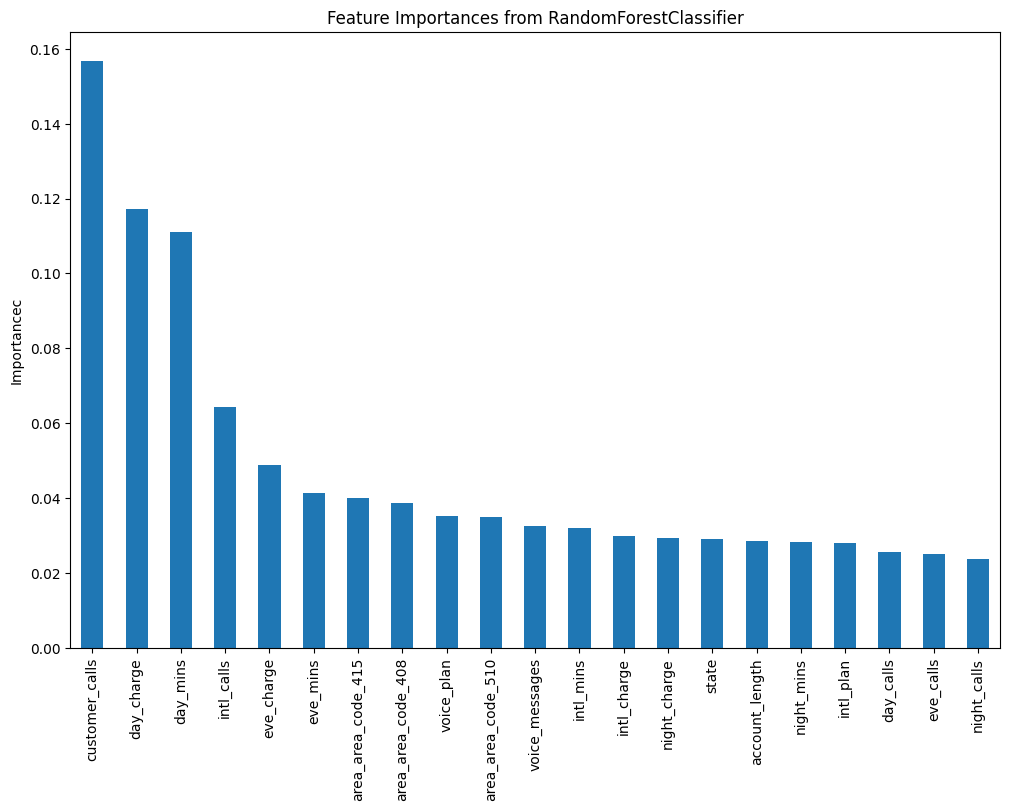

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_resampled, y_resampled)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort and plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importances from RandomForestClassifier')
plt.ylabel('Importancec')
plt.show()

In [10]:
df.columns

Index(['account_length', 'voice_messages', 'intl_mins', 'intl_calls',
       'intl_charge', 'day_mins', 'day_calls', 'day_charge', 'eve_mins',
       'eve_calls', 'eve_charge', 'night_mins', 'night_calls', 'night_charge',
       'customer_calls', 'voice_plan', 'intl_plan', 'state', 'churn',
       'area_area_code_408', 'area_area_code_415', 'area_area_code_510'],
      dtype='object')

In [11]:
df = df.drop(columns=['account_length','state','voice_plan', 'voice_messages',
       'intl_mins', 'day_calls','eve_calls','night_calls',
       'area_area_code_408', 'area_area_code_415', 'area_area_code_510'])

In [12]:
df.columns

Index(['intl_calls', 'intl_charge', 'day_mins', 'day_charge', 'eve_mins',
       'eve_charge', 'night_mins', 'night_charge', 'customer_calls',
       'intl_plan', 'churn'],
      dtype='object')

account_length,
    intl_calls,
    intl_charge,
    day_mins,
    day_charge,
    eve_mins,
    eve_charge,
    night_mins,
    night_charge,
    customer_calls,
    intl_plan,

### Insights from Random Forest Feature Importance Plot

The Random Forest Classifier has evaluated the importance of each feature in predicting customer churn. Here's what the plot reveals:

*   **Top Predictors**: The features with the highest bars are the most influential in the model's decision-making process. From the graph, `day.mins`, `day.charge`, and `customer.calls` appear to be the most important features, indicating that daily usage patterns and customer service interactions are strong indicators of churn.

*   **Usage-Related Features are Key**: A significant portion of the highly important features are related to usage statistics across different times of the day (`day.mins`, `eve.mins`, `night.mins`) and associated charges (`day.charge`, `eve.charge`, `night.charge`). This suggests that the volume and cost of calls are critical factors.

*   **International Plan and Calls**: `intl.plan`, `intl.calls`, `intl.charge`, and `intl.mins` also show notable importance, implying that international usage and whether a customer has an international plan play a role in churn.

*   **Voice Messages and Account Length**: `voice.messages` and `account.length` (likely the duration of the customer's account) have moderate importance.

*   **Less Important Features**: Features like `state`, `voice.plan`, and the `area_area_code` features (415, 510, 408) show very low importance. This suggests that these features contribute minimally to predicting churn based on this Random Forest model.

In summary, the Random Forest model highlights that daily usage (minutes and charges), customer service interactions, and international usage patterns are the primary drivers for predicting customer churn in this dataset. Features related to geographic area codes appear to have negligible impact.

In [13]:
df['churn'].value_counts()

,count
churn,
0,4293
1,707


In [14]:
df.columns

Index(['intl_calls', 'intl_charge', 'day_mins', 'day_charge', 'eve_mins',
       'eve_charge', 'night_mins', 'night_charge', 'customer_calls',
       'intl_plan', 'churn'],
      dtype='object')

### Understanding Class Imbalance

As you've observed, the `churn` column shows a significant imbalance: 4293 instances of `0` (non-churn) versus 707 instances of `1` (churn). This is a common problem in many classification tasks, especially in areas like fraud detection, disease diagnosis, or, as here, customer churn prediction.

#### Why is Class Imbalance a Problem?

1.  **Biased Models**: Machine learning models, by default, often aim to minimize overall error. With imbalanced data, a model might achieve high accuracy by simply predicting the majority class for all instances. For example, if 90% of your data is non-churn, a model predicting 'non-churn' every time would be 90% accurate, but it would completely fail to identify any actual churners.

2.  **Poor Performance on Minority Class**: The model learns less about the minority class due to fewer examples. This often leads to poor predictive performance for the minority class, which is usually the class of most interest (e.g., detecting actual churners).

3.  **Misleading Evaluation Metrics**: Metrics like accuracy can be deceptive. Precision, recall, F1-score, and AUC-ROC are often more appropriate for evaluating models on imbalanced datasets, as they provide a clearer picture of how well the model identifies the minority class.





In [15]:
x = df.drop('churn',axis=1)
y = df['churn']
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,  random_state=42)

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, Y_resampled = smote.fit_resample(x_train, y_train)

In [17]:
Y_resampled.value_counts()

,count
churn,
0,3432
1,3432


In [18]:
rf_balanced = BalancedRandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_resampled, Y_resampled)

y_pred_rf_balanced = rf_balanced.predict(x_test)

print("Classification Report for Balanced Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf_balanced))

Classification Report for Balanced Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       861
           1       0.75      0.81      0.78       139

    accuracy                           0.94      1000
   macro avg       0.86      0.88      0.87      1000
weighted avg       0.94      0.94      0.94      1000



### Insights from Balanced Random Forest Classifier Classification Report

Now, let's examine the performance of the `BalancedRandomForestClassifier` and compare it to the standard `RandomForestClassifier` and `LogisticRegression`:

*   **Overall Accuracy (0.94)**: Slightly lower than the standard Random Forest's 0.96. This is expected as balancing techniques often prioritize the minority class's performance, which can sometimes lead to a small dip in overall accuracy if the majority class performance is slightly affected.

*   **Class 0 (Non-Churn - Majority Class)**:
    *   **Precision (0.97)**: Still very high. When predicting non-churn, the model is correct 97% of the time.
    *   **Recall (0.95)**: Slightly lower than the standard Random Forest's 0.99. This means 5% of actual non-churners were incorrectly classified as potential churners (False Positives). This is the trade-off for potentially better minority class detection.
    *   **F1-score (0.96)**: Very strong, indicating good performance for the majority class.

*   **Class 1 (Churn - Minority Class)**:
    *   **Precision (0.75)**: This is lower than the standard Random Forest's 0.95. This means that when the balanced model predicts a customer will churn, it's correct 75% of the time, resulting in more false positives among the predicted churners compared to the standard Random Forest.
    *   **Recall (0.83)**: This is higher than both the Logistic Regression (0.75) and the standard Random Forest (0.76). This indicates the `BalancedRandomForestClassifier` is even better at identifying actual churners, catching 83% of them.
    *   **F1-score (0.79)**: This is slightly lower than the standard Random Forest's 0.84. While recall improved, the drop in precision affected the F1-score.

### Conclusion and Next Steps:

The `BalancedRandomForestClassifier` successfully **increased the recall for the minority 'churn' class (0.83)**, which is often the primary goal when dealing with imbalanced datasets. This means it's better at catching actual churners. However, this came at the cost of **lower precision for the 'churn' class (0.75)**, meaning more non-churners are incorrectly flagged as churners (false positives).

**Decision Point:**

*   **If your priority is to identify as many actual churners as possible (maximize recall)**, even if it means some false positives, then the `BalancedRandomForestClassifier` is a good choice. This is often the case in churn prediction, where early intervention with potentially churning customers is valuable.
*   **If your priority is to be highly confident that a predicted churner is indeed a churner (maximize precision)**, to avoid wasting resources on false alarms, then the standard `RandomForestClassifier` (which had 0.95 precision for churn) might be preferred.

Both models offer different trade-offs. The choice depends on the specific business implications of false positives versus false negatives in your churn prevention strategy. You now have two strong Random Forest models with different characteristics to choose from, depending on your risk tolerance and the cost of intervention.

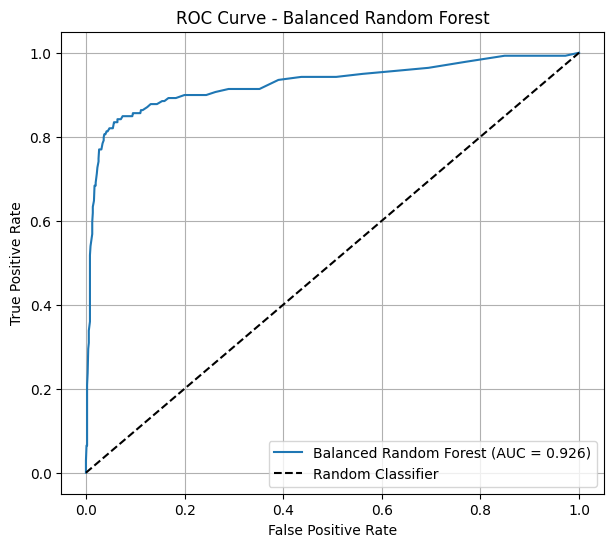

ROC-AUC Score: 0.9259686327592979


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_prob = rf_balanced.predict_proba(x_test)[:, 1]
y_pred = (y_prob >= 0.40).astype(int)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Balanced Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Balanced Random Forest')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print("ROC-AUC Score:", auc_score)

In [22]:
from sklearn.pipeline import Pipeline
import joblib
import os

pipeline = Pipeline([
    ('rf_balanced', BalancedRandomForestClassifier())
])

pipeline.fit(x_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, 'models/telecom_pipeline.pkl')

['models/telecom_pipeline.pkl']